In [17]:

# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write, read
from IPython.display import Audio
import IPython

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import sawtooth, square
from IPython.display import Audio, HTML
    
%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

import soundfile as sf
from urllib.request import urlopen
import io

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")





Wavefolding is a special case of waveshaping, working with **periodic transfer functions**. Depending on the pre-gain, the source signal gets *folded* back, once a maximum of the transfer function is reached. Compared to the previously introduced soft clipping or other methods of waveshaping, this adds many strong harmonics.
  
# Periodic Shaping Function  
  
A simple basic transfer function is a sine with the appropriate scaling factor.
The pre-gain $g$ is the parameter for controling the intensity of the folding effect:


$$
y[n] = \sin \left( g \frac{\pi}{2} x[n] \right) 
$$
 
 
For an input signal $x$, limited to values between $-1$ and $1$,
respectively for gains $g\leq1$,
this results in a sinusoidal waveshaping function with saturation:

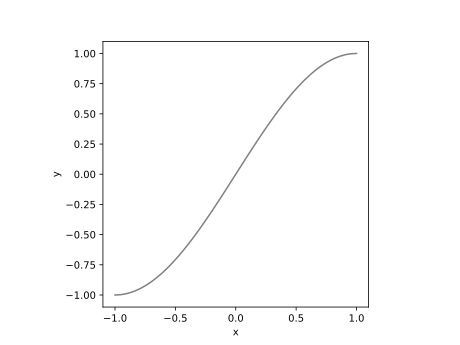

In [52]:
plt.figure()

x = np.linspace(-1,1,100);

plt.plot(x,np.sin(np.pi/2 * x),color = [0.5,0.5,0.5]);

plt.xlabel('x')
plt.ylabel('y')
plt.axis('square')
plt.show()

When the input signal exceeds the boundaries $-1$ and $1$, the signal does not further clip
but is folded back. This can be controller by amplifying the input with an additional gain:


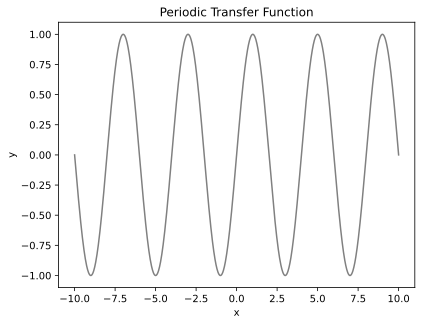

In [20]:

x = np.linspace(-10,10,1000);

plt.plot(x,np.sin(np.pi/2 * x),color = [0.5,0.5,0.5]);

plt.xlabel('x')
plt.ylabel('y')
plt.title('Periodic Transfer Function')
plt.show()

----

# Wavefolding with Different Pre-Gains

The following plots show the output of a wavefolder with the above plotted characteristic at different gains $g$:

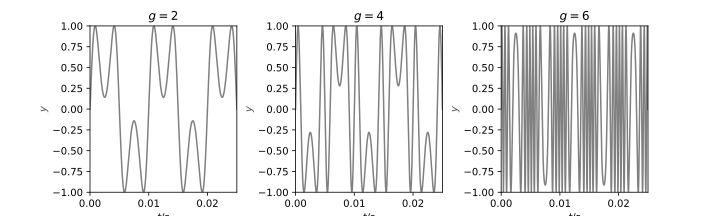

In [48]:
# define wavefolding function

def wavefolder(x, f, g):    
    y = np.sin(x*g)
    return(y)

# basic parameters
fs = 48000
L  = 48000

t  = np.linspace(0,1,L)
f  = np.linspace(-0.5,0.5,L)

x    = np.sin(2*np.pi*100*t)

gain = 3
y1    = wavefolder(x,0,gain)

gain = 6
y2    = wavefolder(x,0,gain)

gain = 20
y3    = wavefolder(x,0,gain)


f = plt.figure(figsize=(10,3))

ax1  = f.add_subplot(131)
ax2 = f.add_subplot(132)
ax3 = f.add_subplot(133)


line, = ax1.plot(t,y1,color = [0.5,0.5,0.5])
ax1.set_xlabel('$t/$s')
ax1.set_ylabel('$y$' ,color = [ 0.3, 0.3, 0.3])
ax1.set_xlim(0, 0.025) 
ax1.set_ylim(-1, 1) 
ax1.set_title('$g=3$')


line, = ax2.plot(t,y2,color = [0.5,0.5,0.5])
ax2.set_xlabel('$t/$s')
ax2.set_ylabel('$y$' ,color = [ 0.3, 0.3, 0.3])
ax2.set_xlim(0, 0.025) 
ax2.set_ylim(-1, 1) 
ax2.set_title('$g=6$')



line, = ax3.plot(t,y3,color = [0.5,0.5,0.5])
ax3.set_xlabel('$t/$s')
ax3.set_ylabel('$y$' ,color = [ 0.3, 0.3, 0.3])
ax3.set_xlim(0, 0.025) 
ax3.set_ylim(-1, 1) 
ax3.set_title('$g=20$')

plt.subplots_adjust(wspace=0.4, hspace=1)

plt.show()


The strong distortion of the original waveform is clearly visble in the time domain plots.
The respective frequency domain plots show prominent overtones. For high gains these   

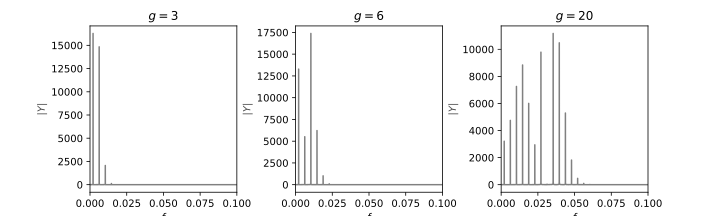

In [51]:
# define wavefolding function

def wavefolder(x, f, g):    
    y = np.sin(x*g)
    return(y)

# basic parameters
fs = 48000
L  = 48000

t  = np.linspace(0,1,L)
f  = np.linspace(-0.5,0.5,L)

x    = np.sin(2*np.pi*100*t)

gain = 3
y1    = abs(np.fft.fft(wavefolder(x,0,gain)))

gain = 6
y2    = abs(np.fft.fft(wavefolder(x,0,gain)))

gain = 20
y3    = abs(np.fft.fft(wavefolder(x,0,gain)))


f = plt.figure(figsize=(10,3))

ax1 = f.add_subplot(131)
ax2 = f.add_subplot(132)
ax3 = f.add_subplot(133)


line, = ax1.plot(t,y1,color = [0.5,0.5,0.5])
ax1.set_xlabel('$f$')
ax1.set_ylabel('$|Y|$' ,color = [ 0.3, 0.3, 0.3])
ax1.set_xlim(0, 0.1) 
ax1.set_title('$g=3$')


line, = ax2.plot(t,y2,color = [0.5,0.5,0.5])
ax2.set_xlabel('$f$')
ax2.set_ylabel('$|Y|$' ,color = [ 0.3, 0.3, 0.3])
ax2.set_xlim(0, 0.1) 
ax2.set_title('$g=6$')



line, = ax3.plot(t,y3,color = [0.5,0.5,0.5])
ax3.set_xlabel('$f$')
ax3.set_ylabel('$|Y|$' ,color = [ 0.3, 0.3, 0.3])
ax3.set_xlim(0, 0.1) 
ax3.set_title('$g=20$')

plt.subplots_adjust(wspace=0.4, hspace=1)

plt.show()


----

# Spectrum for a Sinusoidal Input

The spectrum of wavefolding can be calculated by expressing the folding term as a Fourier series:
The [Jacobi–Anger expansion](https://en.wikipedia.org/wiki/Jacobi%E2%80%93Anger_expansion) can be used for this purpose, with the pre-gain $g$:

$$
\sin \left( g \sin(x) \right) = 2 \sum\limits_{m=1}^{\infty} J_{2m-1}(g)  \sin \left( (2m-1) x \right)
$$

At this point it is already apparent that the resulting signal contains harmonics at 
odd integer multiples of the fundamental frequency $f_m = 100 \mathrm{Hz}\ (2 m -1)$.
Their gain is determined by first kind Bessel functions $J_{2m-1}(g)$:

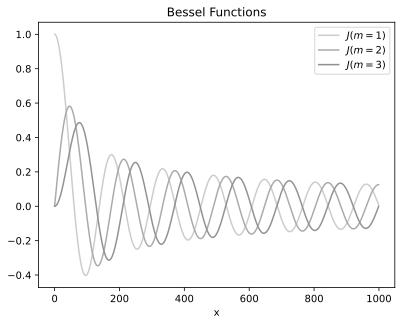

In [45]:
from scipy.special import jv

x = np.linspace(0,40,1000)

y = np.zeros(1000)

plt.figure()


for i in range(3):

    y = jv(i,x)

    plt.plot(y,color = np.array([4, 4, 4])/(i+5))

plt.xlabel('x');
plt.title('Bessel Functions')

plt.legend([
    '$J(m=1)$',
    '$J(m=2)$',
    '$J(m=3)$'])

plt.show()


For the DFT this leads to:


$$
\begin{eqnarray}
X[k] &=& 
2 \sum\limits_{m=1}^{\infty} J_{2m-1}(g)  \sin((2m-1)x)
\sum\limits_{n=0}^{N-1} e^{-j 2 \pi k \frac{n}{N}} \\
%
%
%
X[k]  &=& 
2 \sum\limits_{n=0}^{N-1}  \sum\limits_{m=1}^{\infty}
J_{2m-1}(g)  \sin((2m-1)x)\ 
e^{-j 2 \pi k \frac{n}{N}} \\
%
%
%
X[k]  &=& 
2 \sum\limits_{n=0}^{N-1}  \sum\limits_{m=1}^{\infty}
J_{2m-1}(g)  
\frac{1}{2} \left( e^{j (2m-1)x} - e^{-j(2m-1)x} \right)   % \sin((2n-1)x)\ 
e^{-j 2 \pi k \frac{n}{N}} \\
%
%
%
X[k]  &=&
\sum\limits_{n=0}^{N-1}  \sum\limits_{m=1}^{\infty}
J_{2m-1}(g)  
\left( e^{-j 2 \pi k \frac{n}{N} + j (2m-1)x } 
- e^{-j 2 \pi k \frac{n}{N} -j(2m-1)x} \right)   % \sin((2n-1)x)\ 
\end{eqnarray}
$$

With $x = 2 \pi \frac{f_0}{f_s} n$

$$
X[k] = \sum\limits_{n=0}^{N-1}  \sum\limits_{m=1}^{\infty}
J_{2m-1}(g)  
\left( e^{-j 2 \pi k \frac{n}{N} + j (2m-1) 2 \pi \frac{f_0}{f_s} } 
- e^{-j 2 \pi k \frac{n}{N} -j(2m-1) 2 \pi \frac{f_0}{f_s}} \right)   % \sin((2n-1)x)\ 
$$

[<sup id="fn1">1</sup>](#fn1-back) Hints on this by [Peyam Tabrizian](https://math.asu.edu/node/4743) can be found here: https://youtu.be/C641y-z3aI0 